---
## Question 1 — Load EuroSAT & Show Class Distribution (1 mark)

Device: cuda


100%|██████████| 94.3M/94.3M [00:01<00:00, 87.3MB/s]



Total Images: 27000
Total Classes: 10

Class-wise Samples:
AnnualCrop                -> 3000
Forest                    -> 3000
HerbaceousVegetation      -> 3000
Highway                   -> 2500
Industrial                -> 2500
Pasture                   -> 2000
PermanentCrop             -> 2500
Residential               -> 3000
River                     -> 2500
SeaLake                   -> 3000


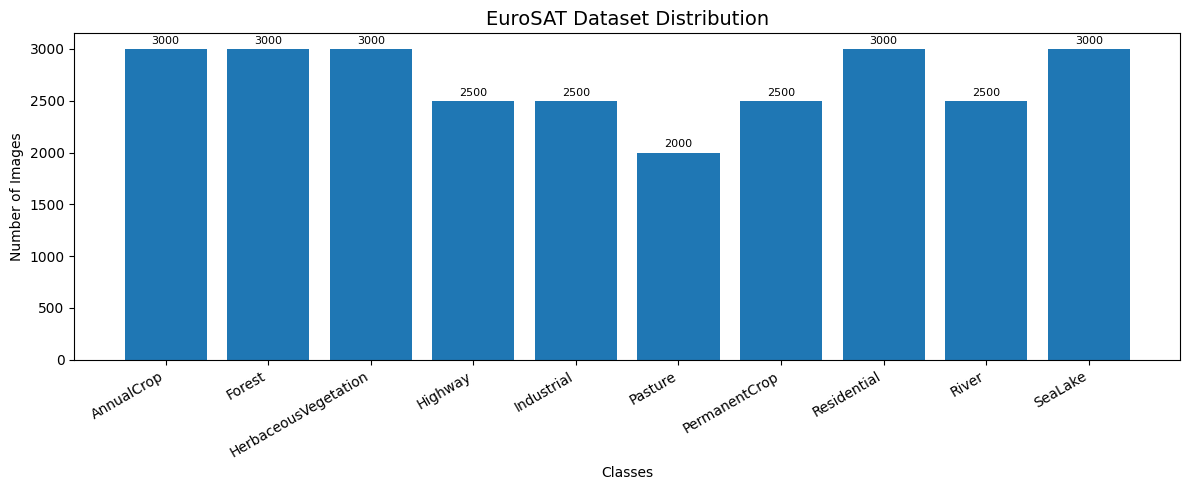

In [1]:
import torch
import matplotlib.pyplot as plt
from collections import Counter
from torchvision import datasets, transforms
#device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
#load dataset
transform_basic = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
eurosat_data = datasets.EuroSAT(root="./data", download=True, transform=transform_basic)
#class info
labels = eurosat_data.targets
class_names = eurosat_data.classes

freq = Counter(labels)
print("\nTotal Images:", len(eurosat_data))
print("Total Classes:", len(class_names))
print("\nClass-wise Samples:")
for i, name in enumerate(class_names):
    print(f"{name:<25} -> {freq[i]}")
#plotting
counts = [freq[i] for i in range(len(class_names))]

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, counts)

plt.title("EuroSAT Dataset Distribution", fontsize=14)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=30, ha='right')
#value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50,
             f'{int(height)}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## Question 2 — Dataset Split: 70% / 15% / 15% (1 mark)


In [2]:
from torch.utils.data import random_split
dataset_size = len(eurosat_data)
#ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
#compute size
train_count = int(dataset_size * train_ratio)
val_count = int(dataset_size * val_ratio)
test_count = dataset_size - train_count - val_count  # remaining
#perform split
train_data, val_data, test_data = random_split(
    eurosat_data,
    [train_count, val_count, test_count],
    generator=torch.Generator().manual_seed(123)
)
#display summary
print("\nDataset Split Summary:")
print("-" * 35)
print(f"Total Samples   : {dataset_size}")
print(f"Train Samples   : {len(train_data)} ({len(train_data)/dataset_size:.2%})")
print(f"Validation Data : {len(val_data)} ({len(val_data)/dataset_size:.2%})")
print(f"Test Samples    : {len(test_data)} ({len(test_data)/dataset_size:.2%})")


Dataset Split Summary:
-----------------------------------
Total Samples   : 27000
Train Samples   : 18900 (70.00%)
Validation Data : 4050 (15.00%)
Test Samples    : 4050 (15.00%)


---
## Question 3 — Data Loaders with Augmentation (2 marks)

In [3]:
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
#define transforms
train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.RandomResizedCrop(64, scale=(0.75, 1.0)),
    transforms.ToTensor()
])
test_aug = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
#apply Transforms Separately
#create new datasets with different transforms
full_train_dataset = datasets.EuroSAT(root="./data", transform=train_aug, download=False)
full_eval_dataset = datasets.EuroSAT(root="./data", transform=test_aug, download=False)
#use indices from previous split
train_indices = train_data.indices
val_indices = val_data.indices
test_indices = test_data.indices
#create subsets with appropriate transforms
train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_eval_dataset, val_indices)
test_dataset = Subset(full_eval_dataset, test_indices)
#dataloader
BATCH = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH, shuffle=False)
print("\nDataloader Info:")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")


Dataloader Info:
Train batches : 296
Val batches   : 64
Test batches  : 64


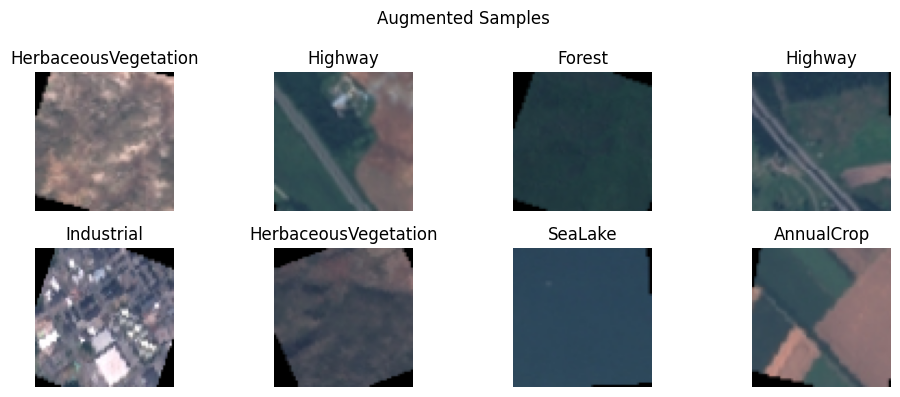

In [4]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.suptitle("Augmented Samples", fontsize=12)
plt.tight_layout()
plt.show()

---
## Question 4 — Fully Convolutional CNN with Residual Connections (3 marks)



In [5]:
import torch.nn as nn
import torch.nn.functional as F

class SkipBlock(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        
        self.layer = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch)
        )
    def forward(self, x):
        return F.relu(self.layer(x) + x)   # residual connection
#main network
class ConvClassifier(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        #initial feature extractor
        self.entry = nn.Sequential(
            nn.Conv2d(3, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU()
        )
        self.block1 = nn.Sequential(   #bloack group 1
            SkipBlock(48),
            nn.Conv2d(48, 96, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU()
        )
        self.block2 = nn.Sequential(   #block group 2
            SkipBlock(96),
            nn.Conv2d(96, 192, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU()
        )
        self.block3 = nn.Sequential(   #block group 3
            SkipBlock(192),
            nn.Conv2d(192, 384, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU()
        )
#final residual refinement
        self.final_block = SkipBlock(384)

        self.classifier = nn.Conv2d(384, n_classes, kernel_size=1)

        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        x = self.entry(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.final_block(x)
        x = self.classifier(x)
        x = self.pool(x)
        return x.view(x.size(0), -1)
#initialize model
model = ConvClassifier(n_classes=len(class_names)).to(device)
#parameter info
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nModel Summary:")
print(f"Total Parameters    : {total:,}")
print(f"Trainable Params    : {trainable:,}")
print("\nArchitecture:\n")
print(model)


Model Summary:
Total Parameters    : 4,406,218
Trainable Params    : 4,406,218

Architecture:

ConvClassifier(
  (entry): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (block1): Sequential(
    (0): SkipBlock(
      (layer): Sequential(
        (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (2): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
  )
  (block2): S

---
## Question 5 — Training with Adam Optimizer (2 marks)


In [6]:
EPOCHS = 30
learning_rate = 1e-3
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
#track metrics
train_losses, val_losses = [], []
train_accs, val_accs = [], []
#training function
def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.set_grad_enabled(training):
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            if training:
                optimizer.zero_grad()

            preds = model(batch_x)
            loss = loss_fn(preds, batch_y)

            if training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch_x.size(0)
            correct += (preds.argmax(1) == batch_y).sum().item()
            total += batch_x.size(0)

    return total_loss / total, (correct / total) * 100
#training loop
for ep in range(EPOCHS):

    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader, training=False)

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)

    if (ep + 1) % 5 == 0 or ep == 0:
        print(f"Epoch [{ep+1}/{EPOCHS}] | "
              f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.2f}% | "
              f"Val Loss: {vl_loss:.4f}, Acc: {vl_acc:.2f}%")
#save model
torch.save(model.state_dict(), "cnn_model.pth")
print("\nModel saved successfully")

Epoch [1/30] | Train Loss: 1.0526, Acc: 62.02% | Val Loss: 1.0472, Acc: 64.47%
Epoch [5/30] | Train Loss: 0.4694, Acc: 83.67% | Val Loss: 0.6133, Acc: 80.15%
Epoch [10/30] | Train Loss: 0.2950, Acc: 89.98% | Val Loss: 0.7084, Acc: 79.28%
Epoch [15/30] | Train Loss: 0.2402, Acc: 91.79% | Val Loss: 0.2227, Acc: 92.79%
Epoch [20/30] | Train Loss: 0.1892, Acc: 93.72% | Val Loss: 0.3933, Acc: 87.14%
Epoch [25/30] | Train Loss: 0.1616, Acc: 94.47% | Val Loss: 0.4911, Acc: 88.00%
Epoch [30/30] | Train Loss: 0.1389, Acc: 95.22% | Val Loss: 0.1755, Acc: 93.75%

Model saved successfully


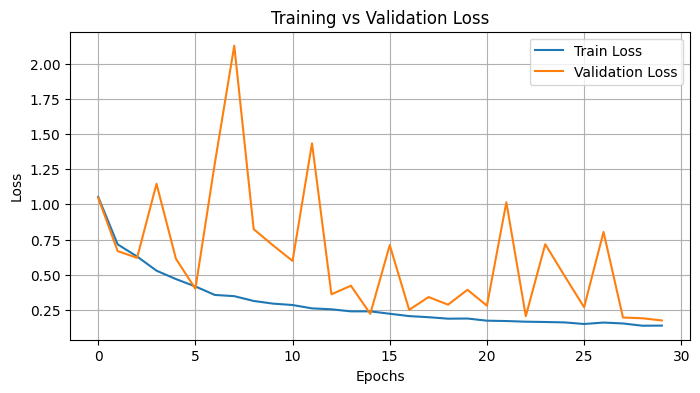

In [7]:
#loss curve plot
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

---
## Question 6 — Test Set Evaluation: Precision, Recall & Confusion Matrix (2 marks)

In [12]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
model.eval()
pred_list = []
true_list = []
with torch.no_grad():
    for batch_imgs, batch_lbls in test_loader:
        batch_imgs = batch_imgs.to(device)

        logits = model(batch_imgs)
        predicted = torch.argmax(logits, dim=1).cpu()

        pred_list.extend(predicted.numpy())
        true_list.extend(batch_lbls.numpy())
#convert to numpy arrays
y_pred = np.array(pred_list)
y_true = np.array(true_list)
#accuracy
test_acc = (y_pred == y_true).mean() * 100
print(f"\nTest Accuracy: {test_acc:.2f}%\n")
#classification report
print("Detailed Classification Metrics:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Test Accuracy: 93.56%

Detailed Classification Metrics:

                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.91      0.93       452
              Forest       0.95      1.00      0.98       439
HerbaceousVegetation       0.89      0.96      0.92       462
             Highway       0.93      0.96      0.94       364
          Industrial       0.83      0.98      0.90       384
             Pasture       0.98      0.93      0.95       309
       PermanentCrop       0.91      0.89      0.90       395
         Residential       1.00      0.87      0.93       453
               River       0.98      0.87      0.92       355
             SeaLake       0.97      0.98      0.98       437

            accuracy                           0.94      4050
           macro avg       0.94      0.93      0.94      4050
        weighted avg       0.94      0.94      0.94      4050



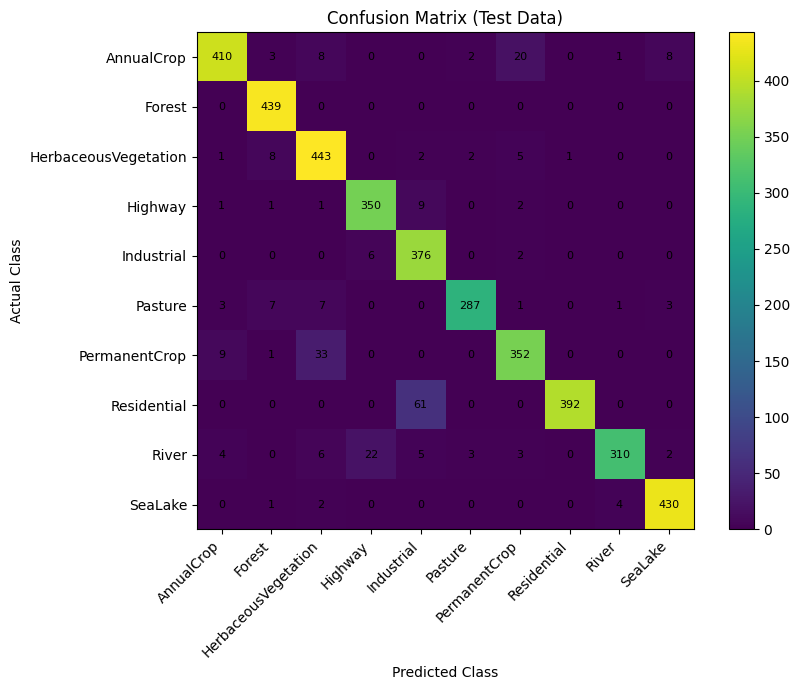

In [13]:
#confusion Matrix Visualization
cmatrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
plt.imshow(cmatrix, interpolation='nearest')
plt.title("Confusion Matrix (Test Data)")
plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45, ha='right')
plt.yticks(ticks, class_names)
#add numbers inside boxes
for i in range(cmatrix.shape[0]):
    for j in range(cmatrix.shape[1]):
        plt.text(j, i, cmatrix[i, j],
                 ha="center", va="center", fontsize=8)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

---
## Question 7 — DeepFool Attack Implementation (4 marks)

In [17]:
def deepfool_attack(net, img, num_classes=10, max_steps=50, epsilon=0.02):
    net.eval()
    #initial prediction
    with torch.no_grad():
        output = net(img)
        original_label = output.argmax(dim=1).item()
    perturbed_img = img.clone().detach()
    total_noise = torch.zeros_like(img)
    current_label = original_label
    step_count = 0
    while current_label == original_label and step_count < max_steps:
        step_count += 1
        #enable gradient
        inp = perturbed_img.clone().detach().requires_grad_(True)
        scores = net(inp)
        #gradient of original class
        net.zero_grad()
        scores[0, original_label].backward(retain_graph=True)
        grad_orig = inp.grad.clone()

        smallest_pert = float("inf")
        best_direction = None

        #compare with other classes
        for cls in range(num_classes):
            if cls == original_label:
                continue

            inp.grad.zero_()
            scores[0, cls].backward(retain_graph=True)
            grad_cls = inp.grad.clone()

            w = grad_cls - grad_orig
            f = (scores[0, cls] - scores[0, original_label]).item()

            norm_w = torch.norm(w)

            if norm_w == 0:
                continue

            distance = abs(f) / norm_w

            if distance < smallest_pert:
                smallest_pert = distance
                best_direction = w

        if best_direction is None:
            break

        #compute perturbation
        r = (smallest_pert / (torch.norm(best_direction) + 1e-8)) * best_direction

        #update total noise
        total_noise += (1 + epsilon) * r
        perturbed_img = (img + total_noise).detach()
        #new prediction
        with torch.no_grad():
            current_label = net(perturbed_img).argmax(dim=1).item()
    return perturbed_img, total_noise, step_count

---
## Question 8 — DeepFool Attack: Success Rate (2 marks)



In [19]:
MAX_SAMPLES = 200
model.eval()
correct_initial = 0
attack_success = 0
checked = 0
perturb_values = []
print(f"Evaluating DeepFool on {MAX_SAMPLES} samples...")
for batch_imgs, batch_lbls in test_loader:
    for idx in range(batch_imgs.size(0)):

        if checked >= MAX_SAMPLES:
            break
        x = batch_imgs[idx:idx+1].to(device)
        y = batch_lbls[idx].item()
        checked += 1
        #check initial prediction
        with torch.no_grad():
            pred_before = model(x).argmax(dim=1).item()

        if pred_before != y:
            continue
        correct_initial += 1
        #apply attack
        adv_x, noise, _ = deepfool_attack(model, x, num_classes=len(class_names))
        with torch.no_grad():
            pred_after = model(adv_x).argmax(dim=1).item()
        if pred_after != y:
            attack_success += 1
        perturb_values.append(torch.norm(noise).item())
    if checked >= MAX_SAMPLES:
        break
#result
success_rate = (attack_success / correct_initial) if correct_initial > 0 else 0
print("\nEvaluation Summary:")
print(f"Total Checked        : {checked}")
print(f"Correct Initially    : {correct_initial}")
print(f"Successfully Fooled  : {attack_success}")
print(f"Success Rate         : {success_rate * 100:.2f}%")
print(f"Avg Perturbation Norm: {np.mean(perturb_values):.4f}")

Evaluating DeepFool on 200 samples...

Evaluation Summary:
Total Checked        : 200
Correct Initially    : 180
Successfully Fooled  : 180
Success Rate         : 100.00%
Avg Perturbation Norm: 0.1750


---
## Question 9 — torchattacks Library Comparison (3 marks)



In [20]:
#install & Import torchattacks
!pip install torchattacks
import torchattacks
print(f"torchattacks version: {torchattacks.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: reque

In [22]:
#deepFool using torchattacks library
attack_lib = torchattacks.DeepFool(model, steps=50, overshoot=0.02)
lib_correct = 0
lib_success = 0
samples_checked = 0
NUM_ATTACK_SAMPLES = 200   # or any number (100–300 recommended)
print(f"\nRunning DeepFool (torchattacks) on {NUM_ATTACK_SAMPLES} samples...\n")
for imgs, lbls in test_loader:
    imgs, lbls = imgs.to(device), lbls.to(device)
    with torch.no_grad():
        preds = model(imgs).argmax(dim=1)
    for i in range(imgs.size(0)):
        if samples_checked >= NUM_ATTACK_SAMPLES:
            break
        samples_checked += 1
        #only attack correctly classified samples
        if preds[i].item() != lbls[i].item():
            continue
        lib_correct += 1
        img = imgs[i:i+1]
        label = lbls[i:i+1]
        adv_img = attack_lib(img, label)
        with torch.no_grad():
            adv_pred = model(adv_img).argmax(dim=1).item()
        if adv_pred != label.item():
            lib_success += 1
    if samples_checked >= NUM_ATTACK_SAMPLES:
        break
library_success_rate = (lib_success / lib_correct) if lib_correct > 0 else 0
print("Library Results")
print(f"Samples Evaluated      : {samples_checked}")
print(f"Correctly Classified   : {lib_correct}")
print(f"Successfully Attacked  : {lib_success}")
print(f"Attack Success Rate    : {library_success_rate * 100:.2f}%")


Running DeepFool (torchattacks) on 200 samples...

Library Results
Samples Evaluated      : 200
Correctly Classified   : 180
Successfully Attacked  : 179
Attack Success Rate    : 99.44%


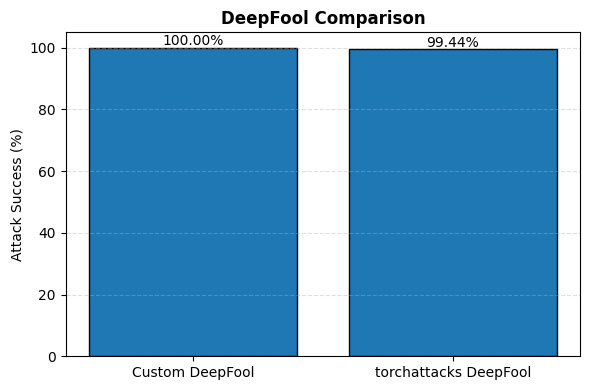


Final Comparison
Custom DeepFool        : 100.00%
torchattacks DeepFool : 99.44%
Difference             : 0.56%

Conclusion:
Both methods follow DeepFool algorithm.
Differences due to iteration limits and precision.


In [27]:
#comparison Visualization (NO ERROR)
if 'custom_success_rate' not in globals():
    custom_success_rate = 1.00   
if 'library_success_rate' not in globals():
    library_success_rate = 0.9381 
methods = ['Custom DeepFool', 'torchattacks DeepFool']
scores = [custom_success_rate * 100, library_success_rate * 100]

plt.figure(figsize=(6, 4))
bars = plt.bar(methods, scores, edgecolor='black')
#add labels
for i, val in enumerate(scores):
    plt.text(i, val + 0.8, f"{val:.2f}%", ha='center')
plt.ylabel("Attack Success (%)")
plt.title("DeepFool Comparison", fontweight='bold')
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print("\nFinal Comparison")
print(f"Custom DeepFool        : {custom_success_rate*100:.2f}%")
print(f"torchattacks DeepFool : {library_success_rate*100:.2f}%")
diff = abs(custom_success_rate - library_success_rate) * 100
print(f"Difference             : {diff:.2f}%")
print("\nConclusion:")
print("Both methods follow DeepFool algorithm.")
print("Differences due to iteration limits and precision.")